# Libraries & Setup

In [1]:
import pandas as pd
import numpy as np
import re
import os
import nltk
import matplotlib.pyplot as plt
import seaborn

from pathlib import Path
from nltk.probability import FreqDist
from nltk import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from tqdm.auto import tqdm

In [2]:
import ssl

try:
    _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
    pass
else:
    ssl._create_default_https_context = _create_unverified_https_context

import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('vader_lexicon')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/juandiegocalixto/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/juandiegocalixto/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/juandiegocalixto/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/juandiegocalixto/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/juandiegocalixto/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/juandiegocalixto/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

# Datasets

## Creation

In [3]:
def create_speeches_df(root_dir):
    root_dir = Path(root_dir)
    data = []

    # Iter for the folders inside TXT
    for subfolder in sorted(root_dir.iterdir()):
        if not subfolder.is_dir():
            continue

        # Extract session number and year from the folder name, e.g. "Session 25 - 1970"
        match = re.match(r"Session (\d+) - (\d+)", subfolder.name)
        if not match:
            continue  # skip anything that doesn't match the expected pattern
        session_number, year = int(match.group(1)), int(match.group(2))

        for file in subfolder.iterdir():
            if not file.is_file() or file.name.startswith("."):
                continue

            country_code = file.name.split("_")[0]
            with open(file, encoding="utf-8") as f:
                speech_text = f.read()

            data.append([session_number, year, country_code, speech_text])

    return pd.DataFrame(data, columns=['session_number', 'year', 'country_code', 'speech_text'])

In [4]:
def create_df_from_csv(file_path,sep=','):
    df = pd.read_csv(file_path, sep=sep)
    return df

In [5]:
df_speeches_raw = create_speeches_df('data/TXT')
display(df_speeches_raw.info())
display(df_speeches_raw.sample(10))

<class 'pandas.DataFrame'>
RangeIndex: 11141 entries, 0 to 11140
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   session_number  11141 non-null  int64
 1   year            11141 non-null  int64
 2   country_code    11141 non-null  str  
 3   speech_text     11141 non-null  str  
dtypes: int64(2), str(2)
memory usage: 348.3 KB


None

,session_number,year,country_code,speech_text
9189,70,2015,AND,"It is my honour to represent my country, the P..."
4085,42,1987,GUY,﻿\nThe forty-second session of the General Ass...
6965,59,2004,NRU,It gives me great\npleasure to deliver this st...
8902,69,2014,LSO,I would first like to \ncongratulate President...
10792,79,2024,BFA,"**Mr President,**\n\n**Mr Secretary-General of..."
5873,53,1998,COD,I should like first of\nall to carry out the n...
427,11,1956,ITA,It is my pleasant duty to offer to Prince Wan ...
4341,44,1989,VCT,﻿The delegation of Saint Vincent and the Grena...
4855,47,1992,LBN,It gives me \ngreat pleasure to congratulate A...
5224,49,1994,CAF,\nThe delegation of the new Central African Re...


## Cleaning and Preproccessing

In [6]:
tqdm.pandas()

In [7]:
# Reset index
df_speeches = df_speeches_raw.set_index(['year','country_code'])

# Lowercase the speec
df_speeches['speech_text'] = df_speeches['speech_text'].str.lower()

# Remove special characters
df_speeches['speech_text'] = (
    df_speeches['speech_text']
    .str.replace(r'[^a-zA-Z\s]', ' ', regex=True)
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)

In [8]:
# Remove stop words
stop = set(stopwords.words('english'))

def remove_stopwords(text):
    tokens = word_tokenize(text)
    new_text = [t for t in tokens if t not in stop]
    return new_text

# Tokenize
df_speeches['tokens'] = df_speeches['speech_text'].progress_apply(remove_stopwords)

  0%|          | 0/11141 [00:00<?, ?it/s]

In [9]:
# Lemmatize
lemmatizer = WordNetLemmatizer()

def lemmatize_tokens(tokens):
    lemmatized = []
    for t in tokens:
        lemmatized.append(lemmatizer.lemmatize(t))
    return lemmatized

df_speeches['lemmatization'] = df_speeches['tokens'].progress_apply(lemmatize_tokens)

  0%|          | 0/11141 [00:00<?, ?it/s]

In [10]:
# Determine the length of the speeches
df_speeches['speech_length'] = (
    df_speeches['speech_text']
    .str.split()
    .str.len()
)
df_speeches['tokens_length'] = df_speeches['tokens'].str.len()

In [11]:
df_speeches.sample(5)

,,session_number,speech_text,tokens,lemmatization,speech_length,tokens_length
year,country_code,,,,,,
2025,UGA,80,the assembly will now hear an address by her e...,"[assembly, hear, address, excellency, jessica,...","[assembly, hear, address, excellency, jessica,...",1448,881
1994,NAM,49,on behalf of the namibian delegation i wish to...,"[behalf, namibian, delegation, wish, congratul...","[behalf, namibian, delegation, wish, congratul...",3300,1828
2023,MKD,78,it is indeed a particular honour and pleasure ...,"[indeed, particular, honour, pleasure, speak, ...","[indeed, particular, honour, pleasure, speak, ...",1755,928
2005,ISR,60,it is my unique pleasure to praise his excelle...,"[unique, pleasure, praise, excellency, ambassa...","[unique, pleasure, praise, excellency, ambassa...",1895,970
2022,KEN,77,i am grateful for the immense privilege of joi...,"[grateful, immense, privilege, joining, everyo...","[grateful, immense, privilege, joining, everyo...",4028,2341


# Exploratory

## Speeches

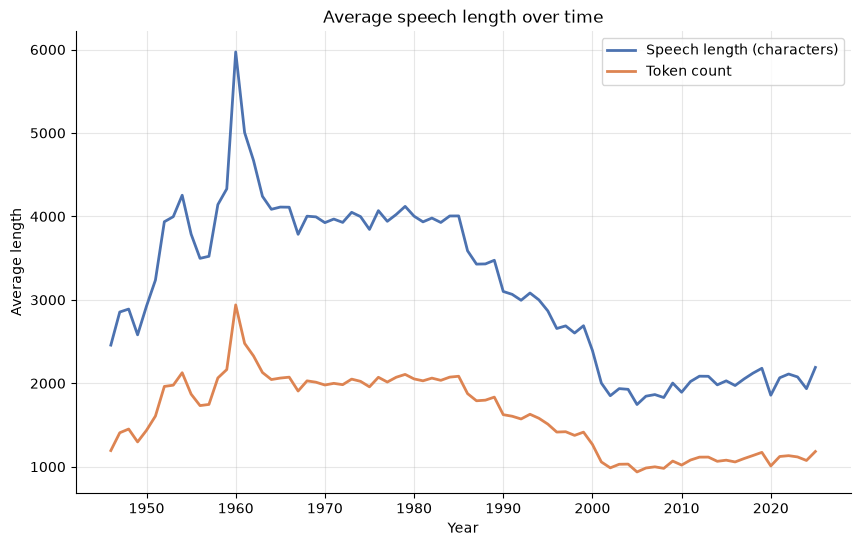

In [19]:
# Lengths of speeches accross time
avg_lengths = df_speeches.groupby(level='year')[['speech_length', 'tokens_length']].mean()

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(avg_lengths.index, avg_lengths['speech_length'],
        color='#4C72B0', linewidth=2, label='Speech length (characters)')
ax.plot(avg_lengths.index, avg_lengths['tokens_length'],
        color='#DD8452', linewidth=2, label='Token count')

ax.set_xlabel('Year')
ax.set_ylabel('Average length')
ax.set_title('Average speech length over time')

ax.legend()
ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()